# Week 1 Exercises

## Homogeneous coordinates

In [1]:
import numpy as np

### Ex 1.1

In [2]:
def homogeneous_2_inhomogeneous(p: np.ndarray) -> np.ndarray:
    '''
    Drop the last coordinate and divide the other coords with it
    '''
    return p[:-1] / p[-1]

p1 = np.array([1, 2, 1])
p2 = np.array([4, 2, 2])
p3 = np.array([6, 4, -1])
p4 = np.array([5, 3, 0.5])

print(homogeneous_2_inhomogeneous(p1))
print(homogeneous_2_inhomogeneous(p2))
print(homogeneous_2_inhomogeneous(p3))
print(homogeneous_2_inhomogeneous(p4))

[1. 2.]
[2. 1.]
[-6. -4.]
[10.  6.]


### Ex 1.2

In [3]:
P1 = np.array([1, 10, -3, 1])
P2 = np.array([2, -4, 1.1, 2])
P3 = np.array([0, 0, -1, 10])
P4 = np.array([-15, 3, 6, 3])

print(homogeneous_2_inhomogeneous(P1))
print(homogeneous_2_inhomogeneous(P2))
print(homogeneous_2_inhomogeneous(P3))
print(homogeneous_2_inhomogeneous(P4))

[ 1. 10. -3.]
[ 1.   -2.    0.55]
[ 0.   0.  -0.1]
[-5.  1.  2.]


### Ex 1.3

In [4]:
import sympy as sp
s, x, y = sp.symbols('s x y')
p_h = np.array([s*x, s*y, s])

# From x + 2y = 3
a = 1
b = 2
c = -3

l = np.array([a, b, c])

### Ex 1.4

In [5]:
p1 = np.array([3, 0, 1])
p2 = np.array([6, 0, 2])
p3 = np.array([1, 1, 2])
p4 = np.array([1, 1, 1])
p5 = np.array([110, -40, 10])
p6 = np.array([11, 4, 1])

print(p1 @ l, p2 @ l, p3 @ l, p4 @ l, p5 @ l, p6 @ l)

0 0 -3 0 0 16


Points p1, p2, p4, and p5 are on the line

### Ex 1.5

In [6]:
l0 = np.array([1, 1, -1])
l1 = np.array([-1, 1, -3])
q_I = np.cross(l0, l1)
print(q_I)

[-2  4  2]


### Ex 1.6

In [7]:
p1, p2, p3 = sp.symbols('p1 p2 p3')
q1, q2, q3 = sp.symbols('q1 q2 q3')
p = np.array([p1, p2, p3])
q = np.array([q1, q2, q3])

A = np.array([
    [10, 0, 2], 
    [0, 10, -3],
    [0, 0, 1]
])

print(f"{A @ p} = {q}")

[10*p1 + 2*p3 10*p2 - 3*p3 p3] = [q1 q2 q3]


### Ex 1.7

In [8]:
def point_to_line_distance(l, p):
    numerator = abs(l @ p)
    denominator = abs(p[2]) * np.sqrt(l[0]**2 + l[1]**2)
    return round(numerator / denominator, 4)

l = np.array([
    1/np.sqrt(2),
    1/np.sqrt(2),
    -1
])

p1 = np.array([0, 0, 1])
p2 = np.array([np.sqrt(2), np.sqrt(2), 1])
p3 = np.array([np.sqrt(2), np.sqrt(2), 4])

print(point_to_line_distance(l, p1))
print(point_to_line_distance(l, p2))
print(point_to_line_distance(l, p3))

1.0
1.0
0.5


*p3* is the shortest distance

### Ex 1.8

In [9]:
l = np.array([
    2,
    2,
    -1
])

print(point_to_line_distance(l, p1))
print(point_to_line_distance(l, p2))
print(point_to_line_distance(l, p3))

0.3536
1.6464
0.1464


## Programming exercises

### Ex 1.9

In [10]:
import cv2
print(cv2.__version__)

4.13.0


### Ex 1.10

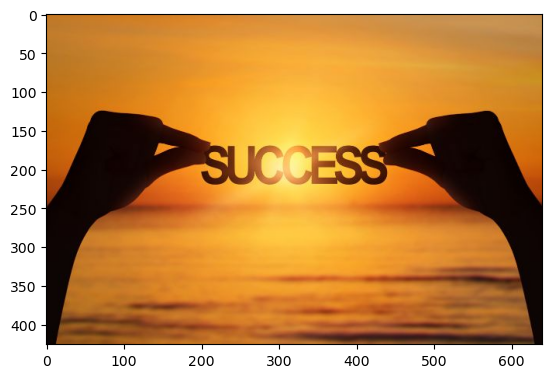

In [11]:
import matplotlib.pyplot as plt

img = cv2.imread('image.png')
img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### Ex 1.11

In [12]:
import itertools as it

def box3d(n=16):
    points = []
    N = tuple(np.linspace(-1, 1, n))
    for i, j in [(-1, -1), (-1, 1), (1, 1), (0, 0)]:
        points.extend(set(it.permutations([(i,)*n, (j,)*n, N])))
    return np.hstack(points)/2

### Ex 1.12

In [13]:
def Pi(p: np.ndarray) -> np.ndarray:
    '''
    Drop the last coordinate and divide the other coords with it
    '''
    return p[:-1] / p[-1]

def PiInv(p: np.ndarray) -> np.ndarray:
    '''
    Inverse of Pi, add a 1 at the end of the vector
    '''
    return np.vstack([p, np.ones((1, p.shape[1]))])

### Ex 1.13

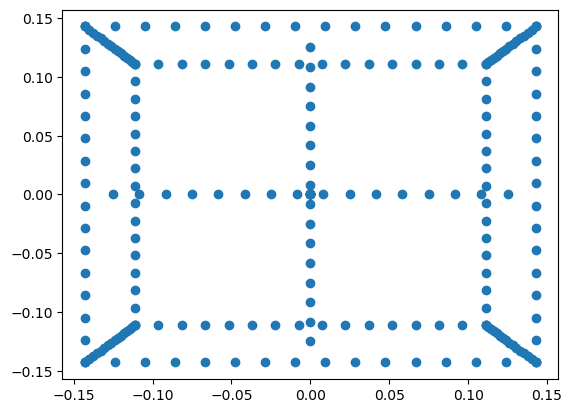

In [14]:
def projectpoints(K: np.ndarray, R: np.ndarray, t: np.ndarray, Q: np.ndarray) -> np.ndarray:
    '''
    Camera matrix K
    Pose of the camera (R)otation, (t)ranslation
    3xn matrix Q, which is n points in 3D to be projected
    '''
    t = t.reshape(3, 1)
    return Pi(K @ (R @ Q + t))

K = np.eye(3)
R = K
t = np.array([0, 0, 4])

Q = box3d()
projected_points = projectpoints(K, R, t, Q)
plt.scatter(projected_points[0], projected_points[1])
plt.show()

### Ex 1.14

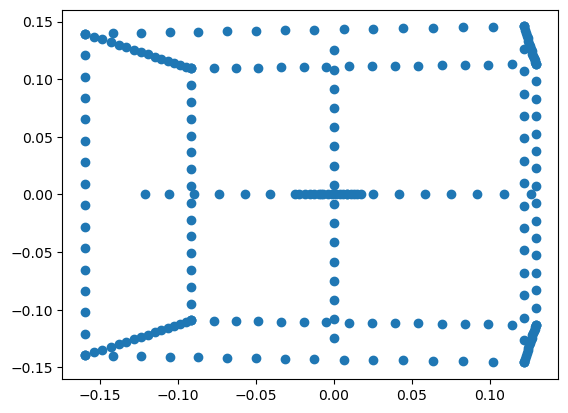

In [15]:

R = lambda theta : np.array([
    [np.cos(theta), 0, np.sin(theta)],
    [0, 1, 0],
    [-np.sin(theta), 0, np.cos(theta)]
])

projected_points = projectpoints(K, R(30), t, Q)
plt.scatter(projected_points[0], projected_points[1])
plt.show()

### Ex 1.15

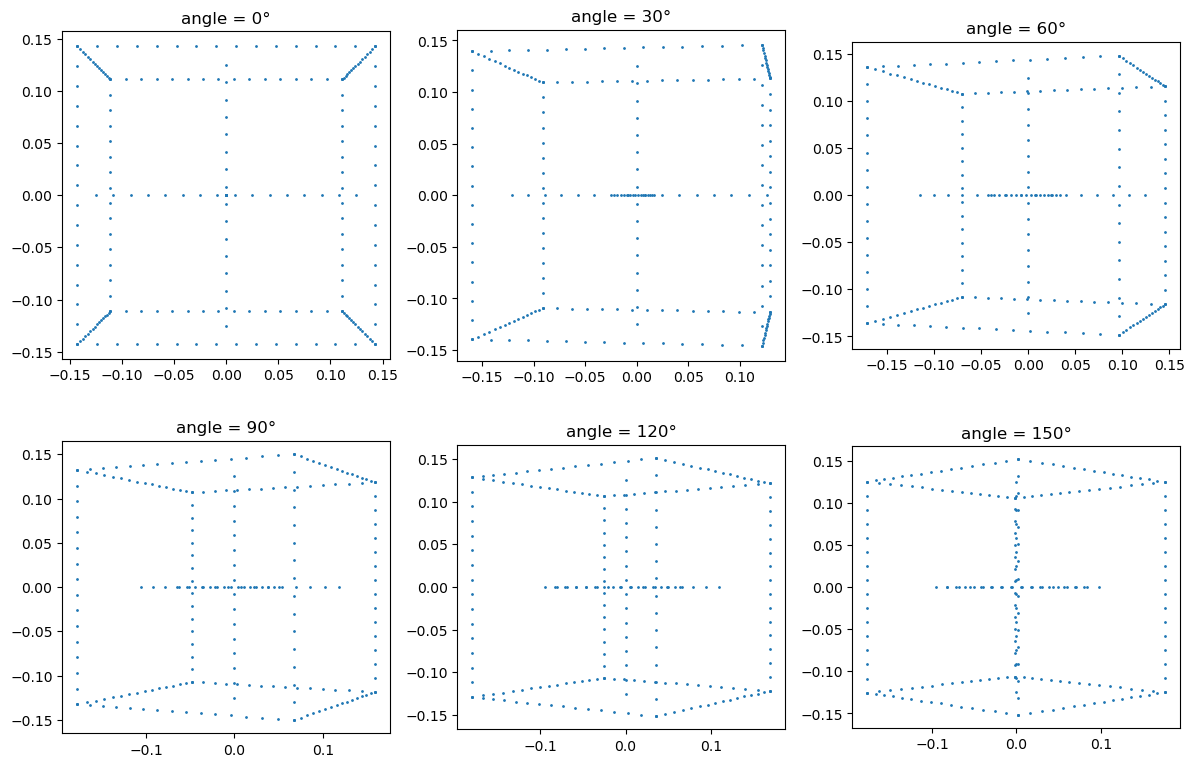

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, angle in zip(axes.flat, range(0, 180, 30)):
    projected_points = projectpoints(K, R(angle), t, Q)
    ax.scatter(projected_points[0], projected_points[1], s=1)
    ax.set_title(f'angle = {angle}°')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

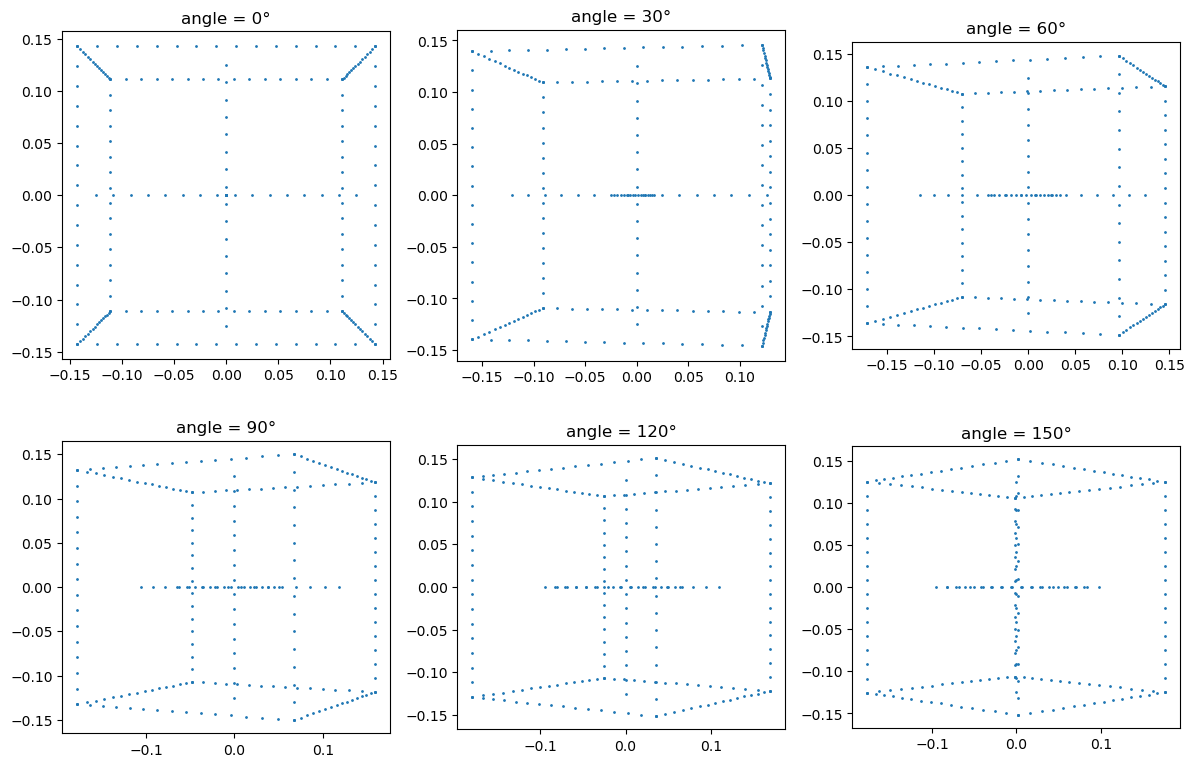

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, angle in zip(axes.flat, range(0, 180, 30)):
    projected_points = projectpoints(K, R(angle), t, Q)
    ax.scatter(projected_points[0], projected_points[1], s=1)
    ax.set_title(f'angle = {angle}°')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

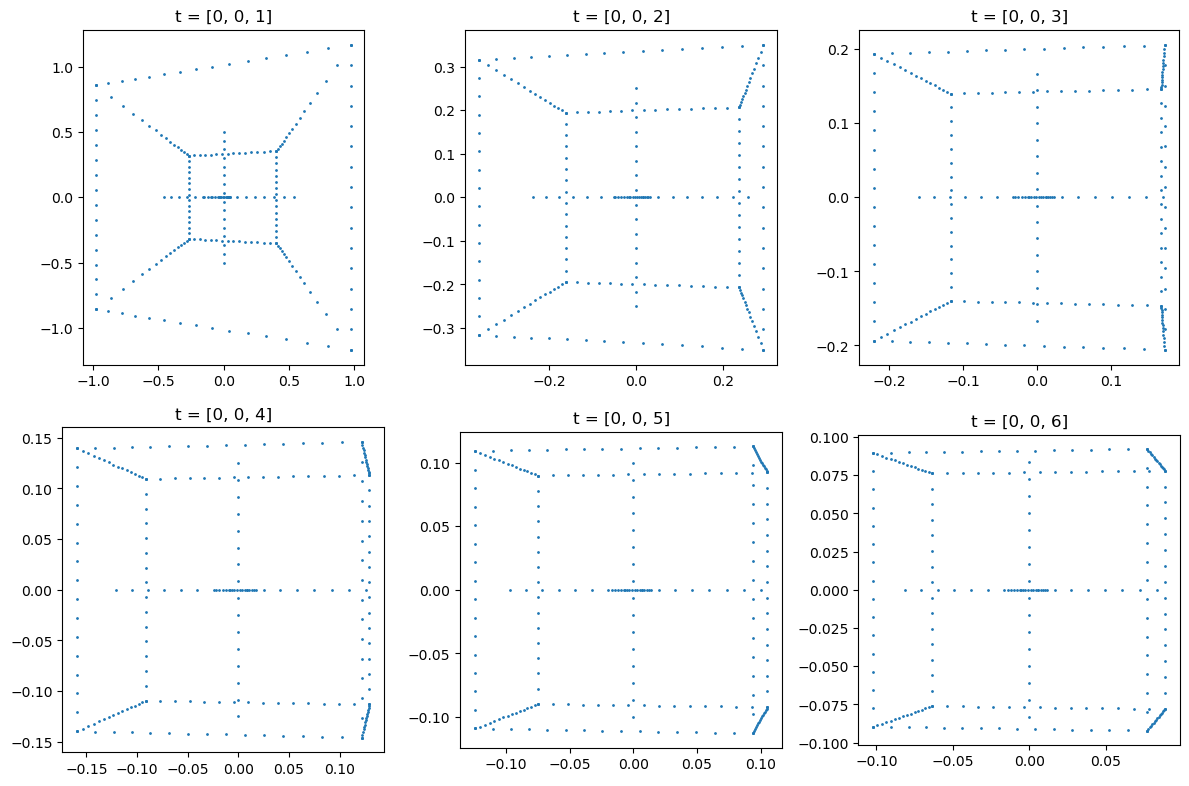

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, t_val in zip(axes.flat, range(0, 6)):
    t = np.array([0, 0, t_val + 1])  # avoid t=0 (division by zero)
    projected_points = projectpoints(K, R(30), t, Q)
    ax.scatter(projected_points[0], projected_points[1], s=1)
    ax.set_title(f't = [0, 0, {t_val + 1}]')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

Interactive plots

In [19]:
def Rx(angle):
    angle = np.deg2rad(angle)
    return np.array([
        [1,           0,            0],
        [0, np.cos(angle), -np.sin(angle)],
        [0, np.sin(angle),  np.cos(angle)]
    ])

%matplotlib qt
from matplotlib.widgets import Slider

fig, ax = plt.subplots(figsize=(6, 6))
plt.subplots_adjust(bottom=0.25)

angle0 = 0
projected_points = projectpoints(K, Rx(angle0) @ R(angle0), t, Q)
scatter = ax.scatter(projected_points[0], projected_points[1], s=1)
ax.set_aspect('equal')
ax.set_xlim(-0.15, 0.15)
ax.set_ylim(-0.15, 0.15)

slider_ax_y = fig.add_axes([0.2, 0.10, 0.6, 0.03])
slider_ax_x = fig.add_axes([0.2, 0.05, 0.6, 0.03])

slider_y = Slider(slider_ax_y, 'Y angle', 0, 30, valinit=angle0, valstep=0.1)
slider_x = Slider(slider_ax_x, 'X angle', 0, 30, valinit=angle0, valstep=0.1)

def update(val):
    angle_y = slider_y.val
    angle_x = slider_x.val
    projected_points = projectpoints(K, Rx(angle_x) @ R(angle_y), t, Q)
    scatter.set_offsets(projected_points.T)
    fig.canvas.draw_idle()

slider_y.on_changed(update)
slider_x.on_changed(update)
plt.show()

In [20]:
%matplotlib qt
from matplotlib.widgets import Slider

fig, ax = plt.subplots(figsize=(6, 6))
plt.subplots_adjust(bottom=0.3)

t0 = np.array([0, 0, 4])
projected_points = projectpoints(K, R(30), t0, Q)
scatter = ax.scatter(projected_points[0], projected_points[1], s=1)
ax.set_aspect('equal')
ax.set_xlim(-0.15, 0.15)
ax.set_ylim(-0.15, 0.15)

slider_ax_x = fig.add_axes([0.2, 0.15, 0.6, 0.03])
slider_ax_y = fig.add_axes([0.2, 0.10, 0.6, 0.03])
slider_ax_z = fig.add_axes([0.2, 0.05, 0.6, 0.03])

slider_x = Slider(slider_ax_x, 'X', -2, 2, valinit=0, valstep=0.01)
slider_y = Slider(slider_ax_y, 'Y', -2, 2, valinit=0, valstep=0.01)
slider_z = Slider(slider_ax_z, 'Z',  1, 10, valinit=4, valstep=0.01)

def update(val):
    t = np.array([slider_x.val, slider_y.val, slider_z.val])
    projected_points = projectpoints(K, R(30), t, Q)
    scatter.set_offsets(projected_points.T)
    fig.canvas.draw_idle()

slider_x.on_changed(update)
slider_y.on_changed(update)
slider_z.on_changed(update)
plt.show()